# LO boundaries, observations, and Salish Sea

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy import crs, feature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.gridspec import GridSpec
import cmocean as cm
import geopandas as gpd

In [2]:
grid = xr.open_dataset('/ocean/rbeutel/MOAD/biogeo_paper/FRDR/grid.nc')
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask201702.nc')

Possible issue encountered when converting Shape #95 to GeoJSON: Shapefile format requires that polygons contain at least one exterior ring, but the Shape was entirely made up of interior holes (defined by counter-clockwise orientation in the shapefile format). The rings were still included but were encoded as GeoJSON exterior rings instead of holes.
Possible issue encountered when converting Shape #95 to GeoJSON: Shapefile format requires that polygons contain at least one exterior ring, but the Shape was entirely made up of interior holes (defined by counter-clockwise orientation in the shapefile format). The rings were still included but were encoded as GeoJSON exterior rings instead of holes.
Possible issue encountered when converting Shape #491 to GeoJSON: Shapefile format requires that polygons contain at least one exterior ring, but the Shape was entirely made up of interior holes (defined by counter-clockwise orientation in the shapefile format). The rings were still included b

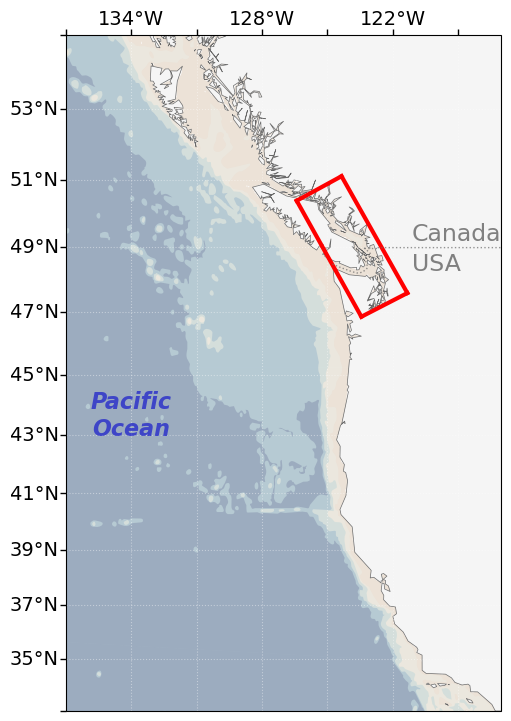

In [3]:
%matplotlib inline
plt.rcParams['font.size'] = 14

###################
# CCS MAP for OSM #
###################

xlim, ylim = [-137, -117], [33, 55]
proj= crs.Mercator(np.mean(xlim), *ylim)

fig = plt.figure(constrained_layout=True, figsize=[5,8])
gs = GridSpec(1, 1, figure=fig)
ax0 = fig.add_subplot(gs[:,:], projection=proj)
ax0.set_extent(xlim+ylim)

# add coastline
ax0.add_feature(feature.GSHHSFeature('low', edgecolor='dimgray', facecolor='whitesmoke', lw=0.5), zorder=2)
ax0.add_feature(feature.BORDERS, linestyle='dotted', edgecolor='dimgray', alpha=0.7, zorder=3)

# Create custom colormap
colors1 = cm.cm.turbid(np.linspace(0, 1, 3))  # First colormap from 0 to 200m
colors2 = cm.cm.ice_r(np.linspace(0, 1, 5))  # Second colormap from 200m to 2000m

# add bathymetry
ax0.add_feature(feature.NaturalEarthFeature(name='bathymetry_L_0', scale='10m', category='physical',facecolor=colors1[1], edgecolor='none',alpha=0.2,zorder=1))
ax0.add_feature(feature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical',facecolor=colors2[0], edgecolor='none',alpha=0.2,zorder=1))
ax0.add_feature(feature.NaturalEarthFeature(name='bathymetry_J_1000', scale='10m', category='physical',facecolor=colors2[1], edgecolor='none',alpha=0.2,zorder=1))
ax0.add_feature(feature.NaturalEarthFeature(name='bathymetry_I_2000', scale='10m', category='physical',facecolor=colors2[2], edgecolor='none',alpha=0.2,zorder=1))
ax0.add_feature(feature.NaturalEarthFeature(name='bathymetry_H_3000', scale='10m', category='physical',facecolor=colors2[3], edgecolor='none',alpha=0.2,zorder=1))

# Add gridlines
xlocs = np.arange(xlim[0],xlim[-1]+1,3)
ylocs = np.arange(ylim[0],ylim[-1]+1,2)
gl = ax0.gridlines(linestyle=":", color='w', alpha=0.4, draw_labels=True, xlocs=xlocs, ylocs=ylocs)
gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
gl.right_labels = False
gl.bottom_labels = False

# Manually add ticks at the grid locations
ax0.set_xticks(xlocs, crs=crs.PlateCarree())  
ax0.set_yticks(ylocs, crs=crs.PlateCarree())
ax0.set_xticklabels([],)  
ax0.set_yticklabels([],)
ax0.tick_params(
    axis='x', direction='out', length=4, width=1, color='black', top=True, bottom=False  # Ticks only on top
)
ax0.tick_params(
    axis='y', direction='out', length=4, width=1, color='black', left=True, right=False  # Ticks only on right
)

# annotations
ax0.text(-121.1, 49.2, 'Canada', c='grey',fontsize=17, transform=crs.PlateCarree(),zorder=8)
ax0.text(-121.1, 48.3, 'USA', c='grey',fontsize=17, transform=crs.PlateCarree(),zorder=8)
ax0.text(-134, 43, 'Pacific\nOcean', transform=crs.PlateCarree(),fontsize=16, color='mediumblue',  weight='bold', fontstyle='italic',horizontalalignment='center',zorder=4,alpha=0.6)
# ax0.text(-123.43, 50, 'Salish Sea', fontstyle='italic', weight='bold', c='mediumblue',fontsize=14,transform=crs.PlateCarree(),zorder=4,alpha=0.6)


# draw red box
x1,x2 = -126.5, -124
y1,y2 = 47.5, 49.5
ax0.plot([mesh.nav_lon[0,0].values,mesh.nav_lon[-1,0].values],[mesh.nav_lat[0,0].values,mesh.nav_lat[-1,0].values],lw=3,color='r',transform=crs.PlateCarree())
ax0.plot([mesh.nav_lon[0,0].values,mesh.nav_lon[0,-1].values],[mesh.nav_lat[0,0].values,mesh.nav_lat[0,-1].values],lw=3,color='r',transform=crs.PlateCarree())
ax0.plot([mesh.nav_lon[-1,0].values,mesh.nav_lon[-1,-1].values],[mesh.nav_lat[-1,0].values,mesh.nav_lat[-1,-1].values],lw=3,color='r',transform=crs.PlateCarree())
ax0.plot([mesh.nav_lon[0,-1].values,mesh.nav_lon[-1,-1].values],[mesh.nav_lat[0,-1].values,mesh.nav_lat[-1,-1].values],lw=3,color='r',transform=crs.PlateCarree())

# plt.savefig("/ocean/rbeutel/MOAD/biogeo_paper/PI_BIOGEO_PAPER/model/figures/OSM_map1.pdf")

In [4]:
def plot_thalweg(ax, T_lon, T_lat):
    lines = np.loadtxt('/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt', delimiter=" ", unpack=False)
    lines = lines.astype(int)

    thalweg_lon = T_lon[lines[:,0],lines[:,1]]
    thalweg_lat = T_lat[lines[:,0],lines[:,1]]
    ax.plot(thalweg_lon, thalweg_lat, 'r', linewidth=1.5, transform=crs.PlateCarree())

In [5]:
# Load mesh and mask files
grid = xr.open_dataset("/home/sallen/MEOPAR/grid/bathymetry_202108.nc", mask_and_scale=False)
coords = xr.open_dataset('/home/sallen/MEOPAR/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)

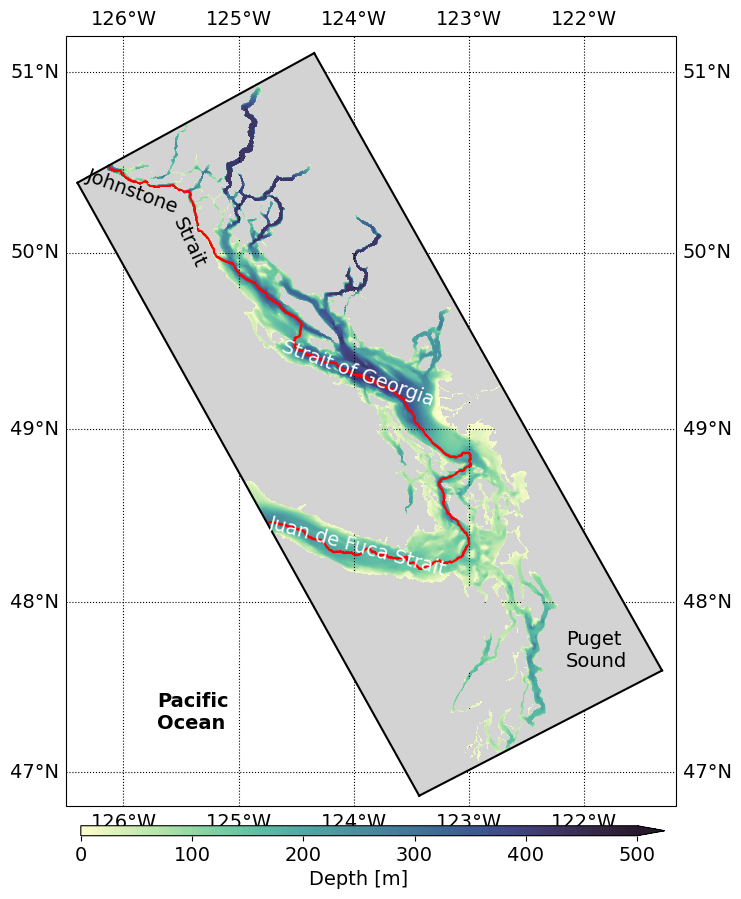

In [6]:
# Increase font size
plt.rcParams['font.size'] = 14

# Make plot area
xlim, ylim = [-126.5, -121.2], [46.8, 51.2]
fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
ax.set_extent(xlim + ylim)

# Depth
c = ax.contourf(
    grid.nav_lon, grid.nav_lat, grid.Bathymetry, levels=np.arange(0, 500.1, 5),
    cmap=cm.cm.deep, extend='max', transform=crs.PlateCarree(), zorder=1,
)
cax = fig.add_axes([0.15, 0.08, 0.73, 0.01])
fig.colorbar(c, cax=cax, orientation='horizontal', label='Depth [m]', ticks=[0,100,200,300,400,500])

# Draw coastline
ax.contourf(mesh.nav_lon, mesh.nav_lat, mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='whitesmoke')
ax.contour(mesh.nav_lon, mesh.nav_lat, mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='gray')

# Draw box
ax.plot(grid['nav_lon'][ :,  0], grid['nav_lat'][ :,  0], 'k-', zorder=6, transform=crs.PlateCarree())
ax.plot(grid['nav_lon'][ :, -1], grid['nav_lat'][ :, -1], 'k-', zorder=6, transform=crs.PlateCarree())
ax.plot(grid['nav_lon'][ 0,  :], grid['nav_lat'][ 0,  :], 'k-', zorder=6, transform=crs.PlateCarree())
ax.plot(grid['nav_lon'][-1,  :], grid['nav_lat'][-1,  :], 'k-', zorder=6, transform=crs.PlateCarree())
ax.contourf(grid['nav_lon'],  grid['nav_lat'], grid['Bathymetry'], [-0.01, 0.01], colors='lightgray', zorder=3, transform=crs.PlateCarree())

# Add gridlines
xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
gl = ax.gridlines(linestyle=":", color='k', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=8)
gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
gl.xlabels_top, gl.ylabels_right = False, False

# # Add annotations
ax.text(0.15, 0.1, 'Pacific\nOcean', weight= "bold",c='k', transform=ax.transAxes, zorder=7)
ax.text(0.82, 0.18, 'Puget\nSound', transform=ax.transAxes, zorder=7)
ax.text(0.33, 0.30, 'Juan de Fuca Strait', c='w',transform=ax.transAxes, rotation=-15,zorder = 8)
ax.text(0.35, 0.52, 'Strait of Georgia', c='w',transform=ax.transAxes, rotation=-20, zorder=7)
ax.text(0.03, 0.77, 'Johnstone', transform=ax.transAxes, rotation=-20, zorder=7)
ax.text(0.17, 0.70, 'Strait',transform=ax.transAxes, rotation=-65, zorder=7)

x, y = coords.nav_lon.values, coords.nav_lat.values
plot_thalweg(ax, x, y)
# ax.text()

In [8]:
data = gpd.read_file('/ocean/rbeutel/MOAD/analysis-becca/projections/Salish_Sea_Bioregion_Census_WA_Tracts_2010_and_BC_SubDivisions_2011_-7680874149833392593.geojson')
data.columns
# from https://salish-sea-atlas-data-wwu.hub.arcgis.com/datasets/a816b0c1cf1f408a8d675447b641f89d_0/explore

Index(['OBJECTID', 'ID_Code', 'County_or_Division', 'Name', 'PopMale',
       'PopFemale', 'TotalPop', 'FemalePercent', 'PopDensity',
       'HispanicLatino_Percent', 'White_Percent', 'Black_Percent',
       'Indigenous_Percent', 'Asian_Percent',
       'HawaiianPacificIslander_Percent', 'OtherRace_Percent',
       'TwoorMoreRaces_Percent', 'Age0to9', 'Age10to14', 'Age15to19',
       'Age20to24', 'Age25to29', 'Age30to34', 'Age35to39', 'Age40to44',
       'Age45to49', 'Age50to54', 'Age55to59', 'Age60to64', 'Age65to69',
       'Age70to74', 'Age75to79', 'Age80to84', 'Age85plus', 'MedianAge',
       'Area_SqKm', 'Land_Area_SqKm', 'geometry'],
      dtype='str')

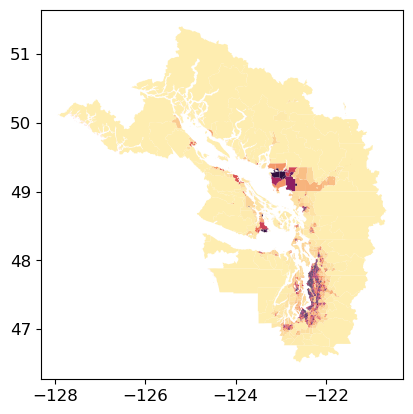

In [9]:
c = data.plot(column='PopDensity',cmap=cm.cm.matter,vmin=10,vmax=2000, )

Possible issue encountered when converting Shape #95 to GeoJSON: Shapefile format requires that polygons contain at least one exterior ring, but the Shape was entirely made up of interior holes (defined by counter-clockwise orientation in the shapefile format). The rings were still included but were encoded as GeoJSON exterior rings instead of holes.
Possible issue encountered when converting Shape #95 to GeoJSON: Shapefile format requires that polygons contain at least one exterior ring, but the Shape was entirely made up of interior holes (defined by counter-clockwise orientation in the shapefile format). The rings were still included but were encoded as GeoJSON exterior rings instead of holes.
Possible issue encountered when converting Shape #491 to GeoJSON: Shapefile format requires that polygons contain at least one exterior ring, but the Shape was entirely made up of interior holes (defined by counter-clockwise orientation in the shapefile format). The rings were still included b

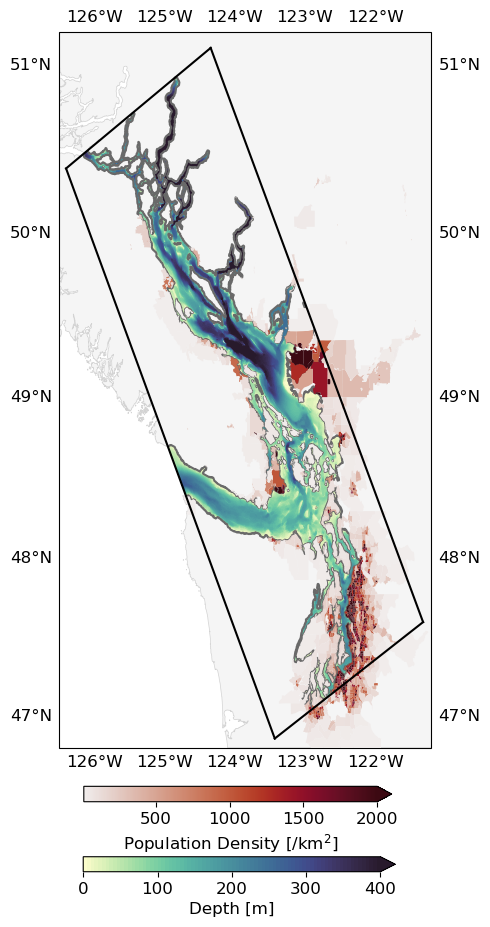

In [10]:
xlim, ylim = [-126.5, -121.2], [46.8, 51.2]
fig, ax = plt.subplots(figsize=(8, 10), subplot_kw={'projection': crs.Mercator(np.mean(xlim), *ylim)})
ax.set_extent(xlim + ylim)

# Depth
c = ax.contourf(
    grid.nav_lon, grid.nav_lat, grid.Bathymetry, levels=np.arange(0, 400.1, 5),
    cmap=cm.cm.deep, extend='max', transform=crs.PlateCarree(), zorder=2,
)
cax = fig.add_axes([0.31, 0.04, 0.39, 0.015])
fig.colorbar(c, cax=cax, orientation='horizontal', label='Depth [m]', ticks=[0,100,200,300,400])

# add coastline
ax.add_feature(feature.GSHHSFeature('full', edgecolor='lightgray', facecolor='whitesmoke', lw=0.5),zorder=1)
ax.contourf(grid['nav_lon'],  grid['nav_lat'], grid['Bathymetry'], [-0.01, 0.01], colors='whitesmoke', transform=crs.PlateCarree(),zorder=3)
ax.contour(grid['nav_lon'],  grid['nav_lat'], grid['Bathymetry'], [-0.01, 0.01], colors='dimgray', transform=crs.PlateCarree(),zorder=3)

#populaiton density
cmap = cm.cm.amp
cmap.set_under('whitesmoke',alpha=0)
data.plot(ax=ax, column='PopDensity',cmap=cmap,vmin=10,vmax=2000, transform=crs.PlateCarree(), zorder=4,legend=True,
          legend_kwds={'label':'Population Density [/km$^2$]','orientation':'horizontal','extend':'max','fraction':0.02,'pad':0.05})

# Draw box
ax.plot(grid['nav_lon'][ :,  0], grid['nav_lat'][ :,  0], 'k-', zorder=6, transform=crs.PlateCarree())
ax.plot(grid['nav_lon'][ :, -1], grid['nav_lat'][ :, -1], 'k-', zorder=6, transform=crs.PlateCarree())
ax.plot(grid['nav_lon'][ 0,  :], grid['nav_lat'][ 0,  :], 'k-', zorder=6, transform=crs.PlateCarree())
ax.plot(grid['nav_lon'][-1,  :], grid['nav_lat'][-1,  :], 'k-', zorder=6, transform=crs.PlateCarree())

# Add gridlines
xlocs, ylocs = [np.arange(np.floor(l[0]), np.ceil(l[1])+1) for l in [xlim, ylim]]
gl = ax.gridlines(linestyle=":", alpha=0, color='w', draw_labels=True, xlocs=xlocs, ylocs=ylocs, zorder=1)
gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
gl.xlabels_top, gl.ylabels_right = False, False

# Manually add ticks at the grid locations
ax0.set_xticks(xlocs, crs=crs.PlateCarree())  
ax0.set_yticks(ylocs, crs=crs.PlateCarree())
ax0.set_xticklabels([],)  
ax0.set_yticklabels([],)
ax0.tick_params(
    axis='x', direction='out', length=4, width=1, color='black', top=True, bottom=False  # Ticks only on top
)
ax0.tick_params(
    axis='y', direction='out', length=4, width=1, color='black', left=True, right=False  # Ticks only on right
)

# x, y = coords.nav_lon.values, coords.nav_lat.values
# plot_thalweg(ax, x, y)

## box decision making

In [11]:
from shapely.geometry import box
from shapely.ops import unary_union

In [32]:
def create_exact_outline(boxes):
    """
    Create a polygon outline that follows the exact boundaries of the provided boxes.

    Parameters:
        boxes (list of list): List of boxes, where each box is [x1, x2, y1, y2].

    Returns:
        shapely.geometry.Polygon: A polygon representing the outline of all boxes.
    """
    # Convert each box to a Shapely Polygon
    polygons = [box(xmin, ymin, xmax, ymax) for ymin, ymax, xmin, xmax in boxes]
    
    # Merge all polygons into a single geometry
    merged_polygon = unary_union(polygons)
    
    # Ensure the result is a Polygon or MultiPolygon and return it
    return merged_polygon

def plot_box(ax, corn):
    ax.plot([corn[2], corn[3], corn[3], corn[2], corn[2]], 
            [corn[0], corn[0], corn[1], corn[1], corn[0]], '-')
    
def plot_poly(ax, poly):
    x,y = poly.exterior.xy
    ax.plot(x,y)

def make_poly4corn(y0, y1, x0, x1):
    return shapely.geometry.Polygon([(x0, y0), (x1, y0), (x1, y1), (x0, y1)])

In [ ]:
# Cassidy inspired boxes

## Puget Sound
PS_main = [0, 150, 90, 315]
PS_AIWB = [150, 205, 235, 320]
PS_WB = [205, 225, 265, 320]
PS_DP = [225, 250, 300, 320]

## Juan de Fuca
JdF2 = [220, 325, 150, 200]
JdF1 = [250, 430, 20, 150]  ## West

## Strait of Georgia
Fraser_plume = [390, 460, 240, 300]
SoG_center1 = [460, 540, 180, 300]
SoG_north = [590, 730, 100, 230]


PS_all = [PS_main, PS_AIWB, PS_WB, PS_DP]
JdFW_all = [JdF1,JdF2]
SoGN_all = [SoG_north]
SoGC_all = [SoG_center1, Fraser_plume]

regions_all = [PS_all, JdFW_all, SoGN_all, SoGC_all]

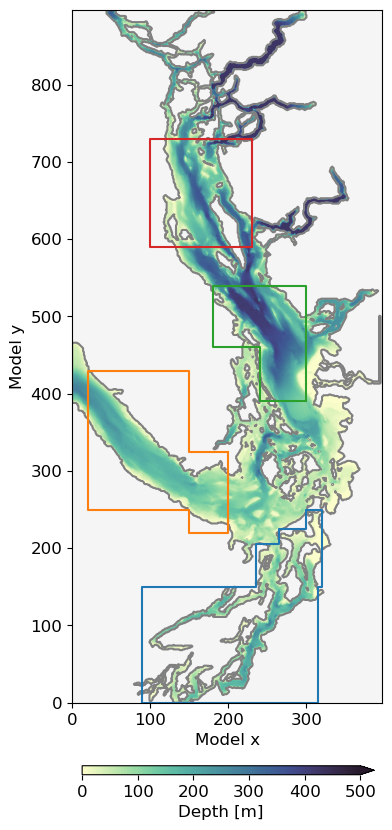

In [33]:
# Cassidy inspired boxes 

# first make boxes on model plot

# Increase font size
plt.rcParams['font.size'] = 12

# Make plot area
fig, ax = plt.subplots(figsize=(4, 9))

# Depth
c = ax.contourf(
    grid.x, grid.y, grid.Bathymetry, levels=np.arange(0, 500.1, 5),
    cmap=cm.cm.deep, extend='max', zorder=1,
)
cax = fig.add_axes([0.15, 0.03, 0.73, 0.01])
fig.colorbar(c, cax=cax, orientation='horizontal',label='Depth [m]', ticks=[0,100,200,300,400,500])

ax.set_xlabel("Model x")
ax.set_ylabel("Model y")

# Draw coastline
ax.contourf(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='whitesmoke')
ax.contour(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='gray')

## Puget Sound
puget_sound_poly = create_exact_outline(PS_all)
plot_poly(ax, puget_sound_poly)

## Juan de Fuca
JdFW_poly = create_exact_outline(JdFW_all)
plot_poly(ax, JdFW_poly)

## Strait of Georgia

SoGC_poly = create_exact_outline(SoGC_all)
plot_poly(ax, SoGC_poly)

SoGN_poly = create_exact_outline(SoGN_all)
plot_poly(ax, SoGN_poly)

# # Add annotations
# ax.text(0.81, 0.15, 'Puget\nSound',weight= "bold", transform=ax.transAxes, zorder=7)
# ax.text(0.7, 0.33, 'Haro\nStrait', weight= "bold",transform=ax.transAxes, zorder=7)
# ax.text(0.03, 0.27, 'Juan de Fuca Strait', weight= "bold",c='w',transform=ax.transAxes, rotation=-42,zorder = 8)
# ax.text(0.37, 0.50, 'Strait of Georgia', weight= "bold",c='w',transform=ax.transAxes, rotation=-45, zorder=7)
# ax.text(0.05, 0.90, 'Johnstone', weight= "bold",transform=ax.transAxes, rotation=-35, zorder=7)
# ax.text(0.22, 0.83, 'Strait',weight= "bold",transform=ax.transAxes, rotation=-85, zorder=7)

# plot thalweg
# lines = np.loadtxt('/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt', delimiter=" ", unpack=False)
# lines = lines.astype(int)
# ax.plot(lines[:,1], lines[:,0], 'r', linewidth=1.5)

# ax.text()

In [43]:
# Karyn inspired boxes

## Puget Sound
PS = [[80, 130, 220, 270]]

## Juan de Fuca
JdF = [[310, 360, 50, 100]]

## Strait of Georgia
SoG_center =[[460, 510, 240, 290]]
SoG_north = [[650, 700, 130, 180]]

regions_all = [PS, JdF, SoG_center, SoG_north]

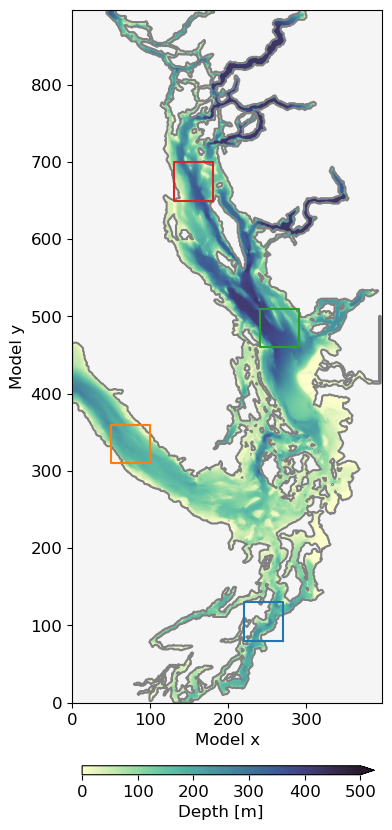

In [44]:
# karyn inspired boxes 

# first make boxes on model plot

# Increase font size
plt.rcParams['font.size'] = 12

# Make plot area
fig, ax = plt.subplots(figsize=(4, 9))

# Depth
c = ax.contourf(
    grid.x, grid.y, grid.Bathymetry, levels=np.arange(0, 500.1, 5),
    cmap=cm.cm.deep, extend='max', zorder=1,
)
cax = fig.add_axes([0.15, 0.03, 0.73, 0.01])
fig.colorbar(c, cax=cax, orientation='horizontal',label='Depth [m]', ticks=[0,100,200,300,400,500])

ax.set_xlabel("Model x")
ax.set_ylabel("Model y")

# Draw coastline
ax.contourf(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='whitesmoke')
ax.contour(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='gray')

## Puget Sound
puget_sound_poly = create_exact_outline(PS)
plot_poly(ax, puget_sound_poly)

## Juan de Fuca
JdFW_poly = create_exact_outline(JdF)
plot_poly(ax, JdFW_poly)

## Strait of Georgia

SoGC_poly = create_exact_outline(SoG_center)
plot_poly(ax, SoGC_poly)

SoGN_poly = create_exact_outline(SoG_north)
plot_poly(ax, SoGN_poly)

# # Add annotations
# ax.text(0.81, 0.15, 'Puget\nSound',weight= "bold", transform=ax.transAxes, zorder=7)
# ax.text(0.7, 0.33, 'Haro\nStrait', weight= "bold",transform=ax.transAxes, zorder=7)
# ax.text(0.03, 0.27, 'Juan de Fuca Strait', weight= "bold",c='w',transform=ax.transAxes, rotation=-42,zorder = 8)
# ax.text(0.37, 0.50, 'Strait of Georgia', weight= "bold",c='w',transform=ax.transAxes, rotation=-45, zorder=7)
# ax.text(0.05, 0.90, 'Johnstone', weight= "bold",transform=ax.transAxes, rotation=-35, zorder=7)
# ax.text(0.22, 0.83, 'Strait',weight= "bold",transform=ax.transAxes, rotation=-85, zorder=7)

# plot thalweg
# lines = np.loadtxt('/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt', delimiter=" ", unpack=False)
# lines = lines.astype(int)
# ax.plot(lines[:,1], lines[:,0], 'r', linewidth=1.5)

# ax.text()